In [61]:
# NECESSARY LIBRARYS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
# READ THE FILE

df = pd.read_csv('/content/vgsales.csv')
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [63]:
# Step 1. Understand the data structure, meta data and data description.
# Explore the structure
# Use it when: Before any cleaning or transformation

# STRUCTURAL OVERVIEW OF THE DATAFRAME
df.info()
# SUMMARY STATISTIC
df.describe()

# INSIGHT Description
# 1. count → Number of non‑missing values.
# 2. mean → Average value.
# 3. std (standard deviation) → How spread out the values are.
# 4. min → Smallest value.
# 5. 25% (Q1) → First quartile (25% of data is below this).
# 6. 50% (Median) → Middle value.
# 7. 75% (Q3) → Third quartile (75% of data is below this).
# 8. max → Largest value.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


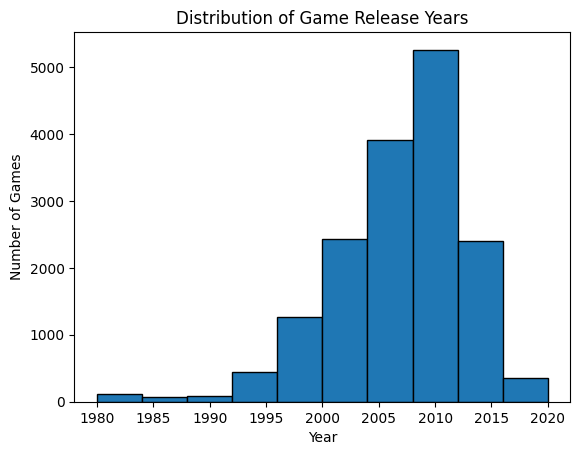

In [64]:
#Histogram of Game Release Years

plt.hist(df['Year'].dropna(), bins=10, edgecolor='black')
plt.title('Distribution of Game Release Years')
plt.xlabel('Year')
plt.ylabel('Number of Games')
plt.show()

# INSIGHT
# The year 2010 had the highest number of game releases compared to all other years.

In [65]:
# Step 2. Clean the Data
# Handle missing values, fix data types, drop bad rows. e.g. Year column has nulls, Name has blanks
# Use it when: Before we start any modelling

df.shape          # how many rows and columns

(16598, 11)

In [66]:
df.dtypes         # what data type each column is

,0
Rank,int64
Name,object
Platform,object
Year,float64
Genre,object
Publisher,object
NA_Sales,float64
EU_Sales,float64
JP_Sales,float64
Other_Sales,float64


In [67]:
df.isnull().sum() # how many missing values per column

,0
Rank,0
Name,0
Platform,0
Year,271
Genre,0
Publisher,58
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0


In [68]:
# Fix 1 — Drop rows with missing Year
# Year is a core column. If you don't know what year a game was released, that row is not useful for trend analysis.

df = df.dropna(subset=['Year'])       # This removes any row where Year is empty.

In [69]:
# Fix 2 — Fill missing Publisher
# Publisher is less critical. Instead of dropping those rows, you can label them as unknown so you don't lose the sales data.

df['Publisher'] = df['Publisher'].fillna('Unknown')       # Fill missing Publisher

In [70]:
# Fix 3 — Fix the Year data type
# After loading, Year is often stored as a float (like 2006.0) instead of a whole number.

df['Year'] = df['Year'].astype(int)     # Fix the Year data type

In [71]:
# Fix 4 — Check for duplicates

df.duplicated().sum()  # how many duplicate rows exist
df = df.drop_duplicates()  # remove them

In [72]:
# Fix 5 — Confirm everything looks clean

print(df.isnull().sum())   # should all be 0 now
print(df.shape)            # see how many rows remain
print(df.dtypes)           # Year should now be int
df.head()                  # eyeball the data

Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64
(16327, 11)
Rank              int64
Name             object
Platform         object
Year              int64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [73]:
# Step 3. EDA - Process of asking questions and finding answers from your data

# QUESTION for this EDA
# 1. Which platform has the most games released?
# 2. Which genre sells the most globally?
# 3. Which publisher released the most games?
# 4. How did global sales trend over the years?
# 5. Which are the top 10 best-selling games of all time?

In [74]:
# Q1 - Which platform has the most games released?

platform_counts = df['Platform'].value_counts()
print(platform_counts.head(10))

Platform
DS      2133
PS2     2127
PS3     1304
Wii     1290
X360    1235
PSP     1197
PS      1189
PC       943
GBA      811
XB       803
Name: count, dtype: int64


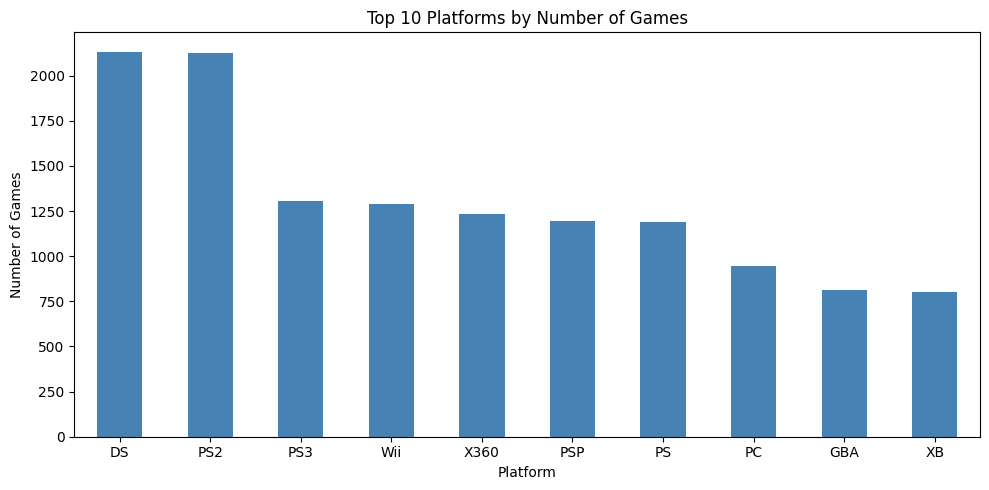

In [75]:
# Q1 - Visualization

platform_counts.head(10).plot(kind='bar', figsize=(10, 5), color='steelblue')

plt.title('Top 10 Platforms by Number of Games')
plt.xlabel('Platform')
plt.ylabel('Number of Games')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [76]:
# Q2 - Which genre sells the most globally?

genre_sales = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)
print(genre_sales)

Genre
Action          1722.88
Sports          1309.24
Shooter         1026.20
Role-Playing     923.84
Platform         829.15
Misc             797.62
Racing           726.77
Fighting         444.05
Simulation       390.16
Puzzle           242.22
Adventure        234.80
Strategy         173.43
Name: Global_Sales, dtype: float64


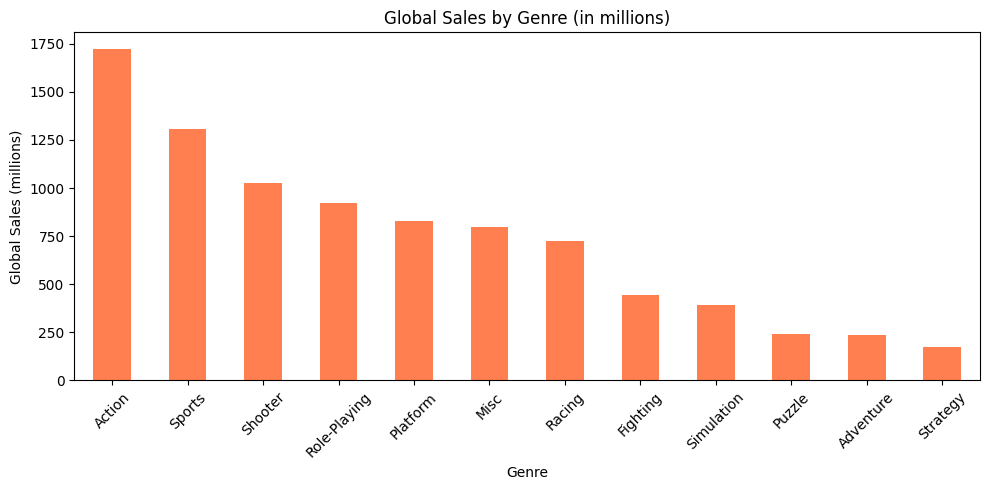

In [77]:
# Q2 - Visualisation

genre_sales.plot(kind='bar', figsize=(10, 5), color='coral')

plt.title('Global Sales by Genre (in millions)')
plt.xlabel('Genre')
plt.ylabel('Global Sales (millions)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [78]:
# Q3 - Which publisher released the most games?

publisher_counts = df['Publisher'].value_counts()
print(publisher_counts.head(10))

Publisher
Electronic Arts                 1339
Activision                       966
Namco Bandai Games               928
Ubisoft                          918
Konami Digital Entertainment     823
THQ                              712
Nintendo                         696
Sony Computer Entertainment      682
Sega                             632
Take-Two Interactive             412
Name: count, dtype: int64


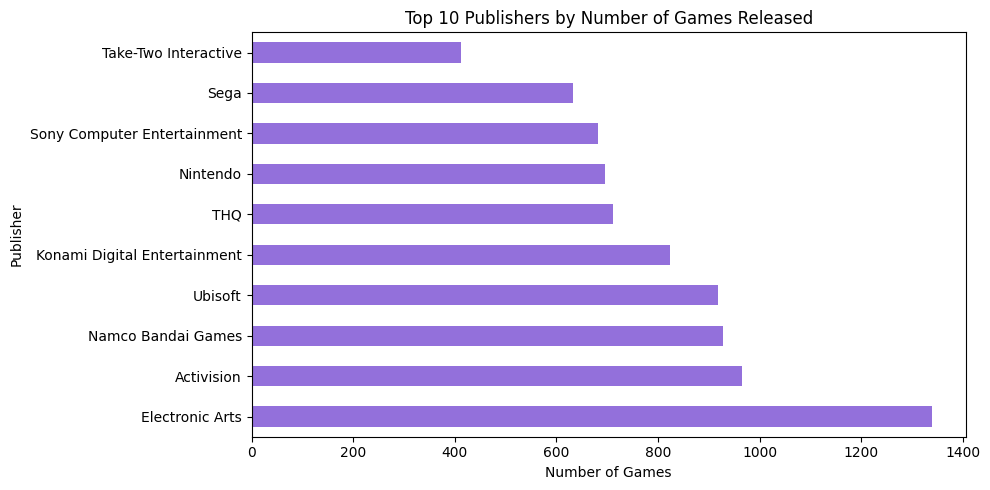

In [79]:
# Q3 - Visualization

publisher_counts.head(10).plot(kind='barh', figsize=(10, 5), color='mediumpurple')

plt.title('Top 10 Publishers by Number of Games Released')
plt.xlabel('Number of Games')
plt.ylabel('Publisher')
plt.tight_layout()
plt.show()

In [80]:
# Comparison made to find whether volume of the game released by publisher has any correlation with the sales made.
# Conclusion here we can see:
# VOLUME =! REVENUE


publisher_sales = df.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False)
print(publisher_sales.head(10))

Publisher
Nintendo                        1784.43
Electronic Arts                 1093.39
Activision                       721.41
Sony Computer Entertainment      607.28
Ubisoft                          473.54
Take-Two Interactive             399.30
THQ                              340.44
Konami Digital Entertainment     278.56
Sega                             270.70
Namco Bandai Games               253.65
Name: Global_Sales, dtype: float64


In [81]:
# Q4 - How did global sales trend over the years?

yearly_sales = df.groupby('Year')['Global_Sales'].sum().sort_values(ascending=False)
print(yearly_sales)

Year
2008    678.90
2009    667.30
2007    611.13
2010    600.45
2006    521.04
2011    515.99
2005    459.94
2004    419.31
2002    395.52
2013    368.11
2012    363.54
2003    357.85
2014    337.05
2001    331.47
2015    264.44
1998    256.47
1999    251.27
2000    201.56
1997    200.98
1996    199.15
1995     88.11
1994     79.17
1992     76.16
1989     73.45
2016     70.93
1985     53.94
1984     50.36
1990     49.39
1988     47.22
1993     45.98
1986     37.07
1981     35.77
1991     32.23
1982     28.86
1987     21.74
1983     16.79
1980     11.38
2020      0.29
2017      0.05
Name: Global_Sales, dtype: float64


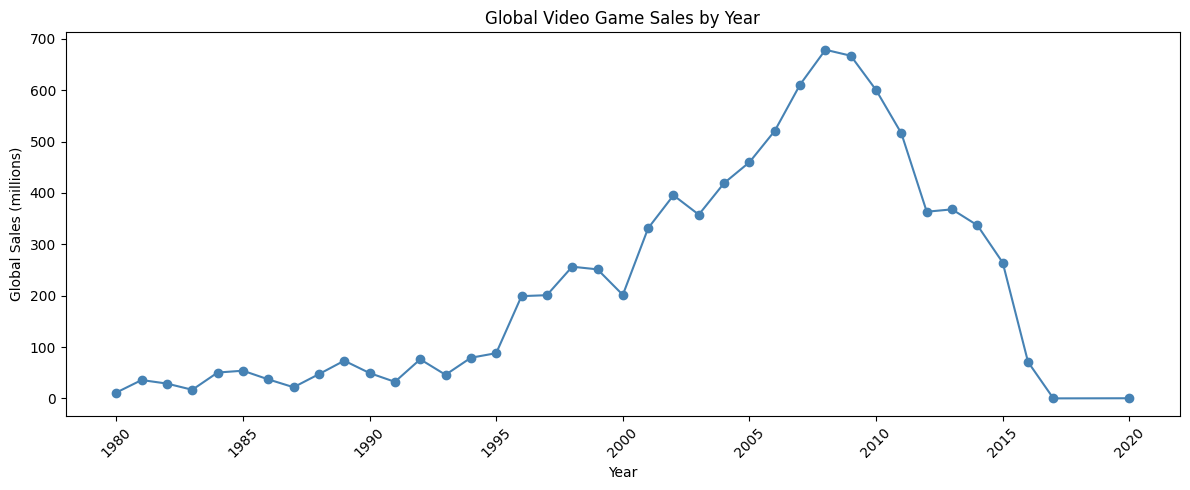

In [82]:
# Q4 - Visualisation

yearly_sales = df.groupby('Year')['Global_Sales'].sum().sort_index()

yearly_sales.plot(kind='line', figsize=(12, 5), color='steelblue', marker='o')

plt.title('Global Video Game Sales by Year')
plt.xlabel('Year')
plt.xticks(rotation=45)
plt.ylabel('Global Sales (millions)')
plt.tight_layout()
plt.show()

In [83]:
# Q5 - Which are the top 10 best-selling games of all time?

top10_games = df[['Name', 'Global_Sales']].sort_values('Global_Sales', ascending=False).head(10)
print(top10_games)

                        Name  Global_Sales
0                 Wii Sports         82.74
1          Super Mario Bros.         40.24
2             Mario Kart Wii         35.82
3          Wii Sports Resort         33.00
4   Pokemon Red/Pokemon Blue         31.37
5                     Tetris         30.26
6      New Super Mario Bros.         30.01
7                   Wii Play         29.02
8  New Super Mario Bros. Wii         28.62
9                  Duck Hunt         28.31


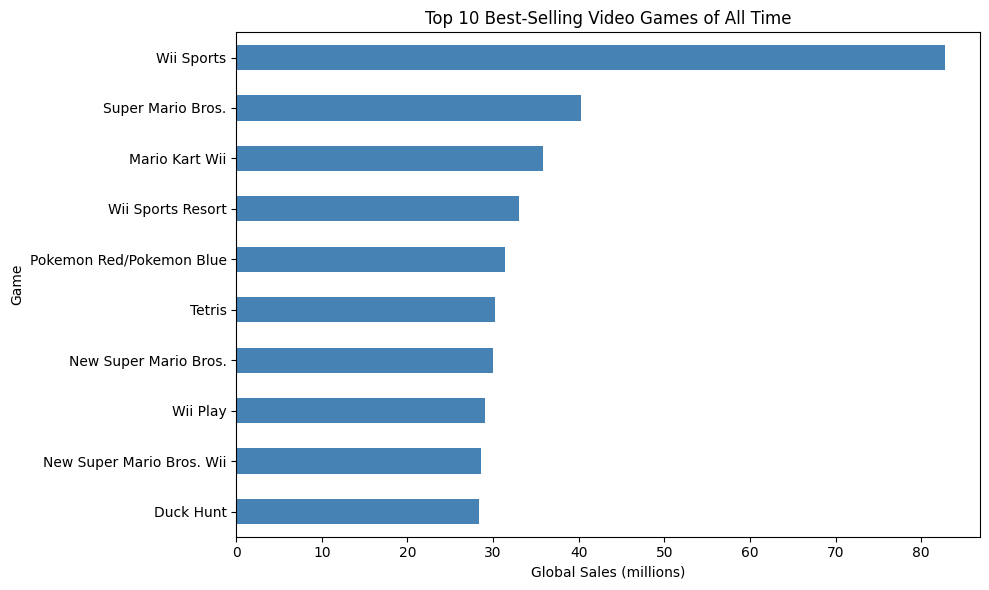

In [84]:
# Q5 - Visualisation

top10_games.plot(kind='barh', x='Name', y='Global_Sales', figsize=(10, 6), color='steelblue', legend=False)

plt.title('Top 10 Best-Selling Video Games of All Time')
plt.xlabel('Global Sales (millions)')
plt.ylabel('Game')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [85]:
# Step 4.a Data Modelling using Star Schema

In [86]:
# Table 1 — dim_game
# This table stores information about each unique game. Every game gets its own ID.

dim_game = df[['Name', 'Genre']].drop_duplicates().reset_index(drop=True)
dim_game.insert(0, 'game_id', range(1, len(dim_game) + 1))
dim_game.columns = ['game_id', 'name', 'genre']

print(dim_game.head())

   game_id                      name         genre
0        1                Wii Sports        Sports
1        2         Super Mario Bros.      Platform
2        3            Mario Kart Wii        Racing
3        4         Wii Sports Resort        Sports
4        5  Pokemon Red/Pokemon Blue  Role-Playing


In [87]:
# Table 2 - dim_platform
# This table stores every unique platform. Same pattern as dim_game — just a different column.

dim_platform = df[['Platform']].drop_duplicates().reset_index(drop=True)
dim_platform.insert(0, 'platform_id', range(1, len(dim_platform) + 1))
dim_platform.columns = ['platform_id', 'platform']

print(dim_platform.head())

   platform_id platform
0            1      Wii
1            2      NES
2            3       GB
3            4       DS
4            5     X360


In [88]:
# Table 3 - dim_publisher
# Same pattern again — unique publishers with their own ID.

dim_publisher = df[['Publisher']].drop_duplicates().reset_index(drop=True)
dim_publisher.insert(0, 'publisher_id', range(1, len(dim_publisher) + 1))
dim_publisher.columns = ['publisher_id', 'publisher']

print(dim_publisher.head())

   publisher_id                    publisher
0             1                     Nintendo
1             2       Microsoft Game Studios
2             3         Take-Two Interactive
3             4  Sony Computer Entertainment
4             5                   Activision


In [89]:
# Table 4 - fact_sales
# This is the most important table — the center of your star.
# Right now your flat table has text like "Nintendo" and "Wii" repeated everywhere. We need to replace that text with IDs that point to your dimension tables.
# The way we do that in pandas is called a merge — same concept as a JOIN in SQL.


fact_sales = df.merge(dim_game, left_on=['Name', 'Genre'], right_on=['name', 'genre'])
fact_sales = fact_sales.merge(dim_platform, left_on='Platform', right_on='platform')
fact_sales = fact_sales.merge(dim_publisher, left_on='Publisher', right_on='publisher')

fact_sales = fact_sales[['game_id', 'platform_id', 'publisher_id', 'Year',
                          'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']]

fact_sales.columns = ['game_id', 'platform_id', 'publisher_id', 'year',
                      'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'global_sales']

print(fact_sales)

       game_id  platform_id  publisher_id  year  na_sales  eu_sales  jp_sales  \
0            1            1             1  2006     41.49     29.02      3.77   
1            2            2             1  1985     29.08      3.58      6.81   
2            3            1             1  2008     15.85     12.88      3.79   
3            4            1             1  2009     15.75     11.01      3.28   
4            5            3             1  1996     11.27      8.89     10.22   
...        ...          ...           ...   ...       ...       ...       ...   
16322    11363            9           187  2002      0.01      0.00      0.00   
16323     2880           19            52  2003      0.01      0.00      0.00   
16324     6565            7             5  2008      0.00      0.00      0.00   
16325    11364            4           506  2010      0.00      0.01      0.00   
16326    10696            9           170  2003      0.01      0.00      0.00   

       other_sales  global_

In [90]:
# Step 4.b Push the star schema data into Big Query.
# Verify your BigQuery setup.


from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery

project_id = 'maindatabase-494310'
client = bigquery.Client(project=project_id)

print("Connected successfully!")

Connected successfully!


In [91]:
# 4.b Step 1 - Create a dataset in BigQuery
# You can do it manually in Big Query.

dataset_id = 'vgsales'

dataset = bigquery.Dataset(f"{project_id}.{dataset_id}")
dataset.location = "US"

client.create_dataset(dataset, exists_ok=True)
print("Dataset created!")

Dataset created!


In [92]:
# 4.b Step 2 - Push all 4 tables


tables = {
    'dim_game': dim_game,
    'dim_platform': dim_platform,
    'dim_publisher': dim_publisher,
    'fact_sales': fact_sales
}

for table_name, df_table in tables.items():
    table_id = f"{project_id}.{dataset_id}.{table_name}"

    job = client.load_table_from_dataframe(df_table, table_id,
          job_config=bigquery.LoadJobConfig(write_disposition="WRITE_TRUNCATE"))
    job.result()
    print(f"Uploaded: {table_name}")

print("All tables uploaded successfully!")

Uploaded: dim_game
Uploaded: dim_platform
Uploaded: dim_publisher
Uploaded: fact_sales
All tables uploaded successfully!
